In [1]:
import subprocess
subprocess.run(["pip", "install", "lightgbm", "scikit-learn",
                "pandas", "numpy", "joblib", "-q"])
print("Done!")

Done!


In [2]:
import pandas as pd
import numpy as np
import ast, joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise         import cosine_similarity
from sklearn.preprocessing            import LabelEncoder, OrdinalEncoder
import lightgbm as lgb

print("Libraries loaded!")

Libraries loaded!


In [3]:
DATA_FOLDER = r"Dataset"  # update to your path

profiles = pd.read_csv(f"{DATA_FOLDER}/profiles.csv")
pairs    = pd.read_csv(f"{DATA_FOLDER}/compatibility_pairs.csv")

print(f"Profiles : {profiles.shape[0]:,}")
print(f"Pairs    : {pairs.shape[0]:,}")

Profiles : 50,000
Pairs    : 4,999,890


In [4]:
def safe_parse(val):
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else []
    except:
        return []

for col in ['skills', 'goals', 'needs', 'can_offer']:
    profiles[f'{col}_list'] = profiles[col].apply(safe_parse)
    profiles[f'{col}_text'] = profiles[f'{col}_list'].apply(lambda x: ' '.join(x))

profiles['about_text'] = profiles['about'].fillna('') if 'about' in profiles.columns else ''

remote_map = {'remote': 2, 'hybrid': 1, 'onsite': 0}
profiles['remote_enc'] = profiles['remote_preference'].str.lower().map(remote_map).fillna(1).astype(int) \
    if 'remote_preference' in profiles.columns else 1

profiles['city'] = profiles['location'].apply(
    lambda x: x.split(',')[0].strip().lower() if isinstance(x, str) else 'unknown'
)

print("Done! Sample skills:", profiles['skills_text'].iloc[0])

Done! Sample skills: Prototyping Go C C NLP


In [5]:
# FIX: fit TF-IDF only on 80% of profiles (training side)
# Then .transform() all 50K profiles using that vocabulary
# → test-side profiles get zero for words not seen in training (correct behaviour)

print("Splitting profiles for TF-IDF fitting...")

np.random.seed(42)
n_profiles    = len(profiles)
perm          = np.random.permutation(n_profiles)
train_cut     = int(n_profiles * 0.8)

train_idx_set = set(perm[:train_cut])   # 40,000 profiles for fitting
train_prof_df = profiles.iloc[list(train_idx_set)]

print(f"  Fitting TF-IDF on {len(train_idx_set):,} profiles (train side)")
print(f"  Transforming all {n_profiles:,} profiles with that vocabulary")

tfidf_skills    = TfidfVectorizer(max_features=300)
tfidf_goals     = TfidfVectorizer(max_features=200)
tfidf_can_offer = TfidfVectorizer(max_features=200)
tfidf_needs     = TfidfVectorizer(max_features=200)
tfidf_about     = TfidfVectorizer(max_features=200)

# .fit() only on training profiles — .transform() on ALL 50K
skills_matrix    = tfidf_skills.fit(train_prof_df['skills_text']).transform(profiles['skills_text'])
goals_matrix     = tfidf_goals.fit(train_prof_df['goals_text']).transform(profiles['goals_text'])
can_offer_matrix = tfidf_can_offer.fit(train_prof_df['can_offer_text']).transform(profiles['can_offer_text'])
needs_matrix     = tfidf_needs.fit(train_prof_df['needs_text']).transform(profiles['needs_text'])
about_matrix     = tfidf_about.fit(train_prof_df['about_text']).transform(profiles['about_text'])

profile_id_to_idx = {pid: i for i, pid in enumerate(profiles['profile_id'])}

print(f"\nSkills matrix : {skills_matrix.shape}")
print(f"Goals matrix  : {goals_matrix.shape}")
print("Done — TF-IDF fitted on training profiles only, no leakage!")

Splitting profiles for TF-IDF fitting...
  Fitting TF-IDF on 40,000 profiles (train side)
  Transforming all 50,000 profiles with that vocabulary

Skills matrix : (50000, 72)
Goals matrix  : (50000, 23)
Done — TF-IDF fitted on training profiles only, no leakage!


In [6]:
def jaccard(list_a, list_b):
    a = set(str(x).lower().strip() for x in list_a)
    b = set(str(x).lower().strip() for x in list_b)
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

print(jaccard(['Python','SQL','ML'], ['Python','SQL','React']))  # expected 0.5

0.5


In [7]:
oe_seniority = OrdinalEncoder(
    categories=[['entry', 'mid', 'senior', 'executive']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
profiles['seniority_ord'] = oe_seniority.fit_transform(
    profiles[['seniority_level']].fillna('entry')
).astype(int)

le_industry = LabelEncoder()
profiles['industry_enc'] = le_industry.fit_transform(profiles['industry'].fillna('unknown'))

le_city = LabelEncoder()
profiles['city_enc'] = le_city.fit_transform(profiles['city'])

print("Seniority encoding — entry:0  mid:1  senior:2  executive:3")
print(profiles[['seniority_level','seniority_ord']].drop_duplicates().sort_values('seniority_ord'))

Seniority encoding — entry:0  mid:1  senior:2  executive:3
  seniority_level  seniority_ord
0           entry              0
2             mid              1
1          senior              2
3       executive              3


In [8]:
# CHANGE from old cell 8:
#   REMOVED skill_cosine — was 1.17% importance, near-useless with short skill lists
#   Now 9 features total — cleaner, faster, no redundancy

def build_features(id_a, id_b):
    ia = profile_id_to_idx.get(id_a)
    ib = profile_id_to_idx.get(id_b)
    if ia is None or ib is None:
        return None

    a, b = profiles.iloc[ia], profiles.iloc[ib]

    exp_a  = float(a['years_experience']) if pd.notna(a['years_experience']) else 0.0
    exp_b  = float(b['years_experience']) if pd.notna(b['years_experience']) else 0.0
    conn_a = max(float(a['connections'])  if pd.notna(a['connections'])  else 1.0, 1.0)
    conn_b = max(float(b['connections'])  if pd.notna(b['connections'])  else 1.0, 1.0)
    sen_a  = int(a['seniority_ord'])
    sen_b  = int(b['seniority_ord'])

    return np.array([
        jaccard(a['skills_list'], b['skills_list']),                           # 1. skill_jaccard
        float(cosine_similarity(goals_matrix[ia], goals_matrix[ib])[0][0]),   # 2. goals_cosine
        abs(exp_a - exp_b),                                                    # 3. exp_gap
        1 if a['industry_enc'] == b['industry_enc'] else 0,                   # 4. same_industry
        abs(sen_a - sen_b),                                                    # 5. seniority_gap
        max(conn_a, conn_b) / min(conn_a, conn_b),                            # 6. conn_ratio
        exp_a + exp_b,                                                         # 7. exp_sum
        1 if (max(sen_a, sen_b) >= 2 and min(sen_a, sen_b) <= 1) else 0,     # 8. mentorship
        2 - abs(int(a['remote_enc']) - int(b['remote_enc']))                  # 9. remote_match
    ], dtype=np.float32)


FEATURE_NAMES = [
    'skill_jaccard', 'goals_cosine', 'exp_gap',
    'same_industry', 'seniority_gap', 'conn_ratio',
    'exp_sum', 'mentorship', 'remote_match'
]

# Quick check — print all 9 values
sample = build_features(profiles['profile_id'].iloc[0], profiles['profile_id'].iloc[1])
print("9 clean features — no skill_cosine:\n")
for name, val in zip(FEATURE_NAMES, sample):
    print(f"  {name:<18} : {val:.4f}")

9 clean features — no skill_cosine:

  skill_jaccard      : 0.0000
  goals_cosine       : 0.0000
  exp_gap            : 7.0000
  same_industry      : 0.0000
  seniority_gap      : 2.0000
  conn_ratio         : 22.3774
  exp_sum            : 11.0000
  mentorship         : 1.0000
  remote_match       : 1.0000


In [9]:
# grouped sampling — guarantees ~100 candidates per person
# percentile labels — balanced ~25% per label instead of 0.7% label-3

NUM_PEOPLE = 10_000
sampled_people = pairs['profile_a_id'].drop_duplicates().sample(n=NUM_PEOPLE, random_state=42)
sample_pairs   = pairs[pairs['profile_a_id'].isin(sampled_people)].reset_index(drop=True)

print(f"Pairs   : {len(sample_pairs):,}")
print(f"People  : {sample_pairs['profile_a_id'].nunique():,}")
print(f"Avg/person : {len(sample_pairs)/sample_pairs['profile_a_id'].nunique():.1f}")

p25 = pairs['compatibility_score'].quantile(0.25)
p50 = pairs['compatibility_score'].quantile(0.50)
p75 = pairs['compatibility_score'].quantile(0.75)
print(f"\nLabel thresholds — 0:<{p25:.1f}  1:<{p50:.1f}  2:<{p75:.1f}  3:>={p75:.1f}")

def score_to_label(s):
    if   s >= p75: return 3
    elif s >= p50: return 2
    elif s >= p25: return 1
    else:          return 0

X_list, y_list, group_ids = [], [], []

for i, row in sample_pairs.iterrows():
    feats = build_features(row['profile_a_id'], row['profile_b_id'])
    if feats is not None:
        X_list.append(feats)
        y_list.append(score_to_label(row['compatibility_score']))
        group_ids.append(row['profile_a_id'])
    if (i + 1) % 20_000 == 0:
        print(f"  {i+1:,} / {len(sample_pairs):,}")

X         = np.vstack(X_list)
y         = np.array(y_list, dtype=np.int32)
group_ids = np.array(group_ids)

print(f"\nX shape : {X.shape}")
print("Label distribution:")
for lbl, cnt in enumerate(np.bincount(y)):
    print(f"  Label {lbl} : {cnt:,}  ({cnt/len(y)*100:.1f}%)")

Pairs   : 999,974
People  : 10,000
Avg/person : 100.0

Label thresholds — 0:<30.6  1:<35.8  2:<42.5  3:>=42.5
  20,000 / 999,974
  40,000 / 999,974
  60,000 / 999,974
  80,000 / 999,974
  100,000 / 999,974
  120,000 / 999,974
  140,000 / 999,974
  160,000 / 999,974
  180,000 / 999,974
  200,000 / 999,974
  220,000 / 999,974
  240,000 / 999,974
  260,000 / 999,974
  280,000 / 999,974
  300,000 / 999,974
  320,000 / 999,974
  340,000 / 999,974
  360,000 / 999,974
  380,000 / 999,974
  400,000 / 999,974
  420,000 / 999,974
  440,000 / 999,974
  460,000 / 999,974
  480,000 / 999,974
  500,000 / 999,974
  520,000 / 999,974
  540,000 / 999,974
  560,000 / 999,974
  580,000 / 999,974
  600,000 / 999,974
  620,000 / 999,974
  640,000 / 999,974
  660,000 / 999,974
  680,000 / 999,974
  700,000 / 999,974
  720,000 / 999,974
  740,000 / 999,974
  760,000 / 999,974
  780,000 / 999,974
  800,000 / 999,974
  820,000 / 999,974
  840,000 / 999,974
  860,000 / 999,974
  880,000 / 999,974
  900,000 / 99

In [10]:
sort_idx  = np.argsort(group_ids, kind='stable')
X         = X[sort_idx]
y         = y[sort_idx]
group_ids = group_ids[sort_idx]

unique_ids, group_sizes = np.unique(group_ids, return_counts=True)

split_point   = int(len(unique_ids) * 0.8)
train_ids_set = set(unique_ids[:split_point])
train_mask    = np.array([gid in train_ids_set for gid in group_ids])
test_mask     = ~train_mask

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]
train_groups     = group_sizes[:split_point]
test_groups      = group_sizes[split_point:]

print(f"Train : {X_train.shape[0]:,} rows | {len(train_groups):,} people")
print(f"Test  : {X_test.shape[0]:,}  rows | {len(test_groups):,}  people")
print(f"Avg candidates/person : {group_sizes.mean():.1f}")

Train : 799,976 rows | 8,000 people
Test  : 199,998  rows | 2,000  people
Avg candidates/person : 100.0


In [11]:
train_data = lgb.Dataset(X_train, label=y_train, group=train_groups, feature_name=FEATURE_NAMES)
test_data  = lgb.Dataset(X_test,  label=y_test,  group=test_groups,  feature_name=FEATURE_NAMES,
                         reference=train_data)

params = {
    'objective'        : 'lambdarank',
    'metric'           : 'ndcg',
    'ndcg_eval_at'     : [5, 10],
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'max_depth'        : 5,
    'min_data_in_leaf' : 20,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.5,
    'verbose'          : -1
}

print("Training LambdaRank...")
model = lgb.train(
    params,
    train_data,
    num_boost_round = 1000,
    valid_sets      = [test_data],
    callbacks       = [lgb.early_stopping(30, verbose=True), lgb.log_evaluation(50)]
)
print(f"Best round : {model.best_iteration}")

Training LambdaRank...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's ndcg@5: 0.97751	valid_0's ndcg@10: 0.973798
[100]	valid_0's ndcg@5: 0.981773	valid_0's ndcg@10: 0.978363
[150]	valid_0's ndcg@5: 0.983523	valid_0's ndcg@10: 0.980132
[200]	valid_0's ndcg@5: 0.984759	valid_0's ndcg@10: 0.980969
[250]	valid_0's ndcg@5: 0.985278	valid_0's ndcg@10: 0.981707
Early stopping, best iteration is:
[232]	valid_0's ndcg@5: 0.98563	valid_0's ndcg@10: 0.981565
Best round : 232


In [12]:
test_scores = model.predict(X_test)

def ndcg_at_k(scores, labels, k):
    order    = np.argsort(scores)[::-1]
    labels   = np.array(labels)
    gains    = 2**labels[order[:k]] - 1
    disc     = np.log2(np.arange(2, len(gains)+2))
    dcg      = np.sum(gains / disc)
    ideal    = np.sort(labels)[::-1][:k]
    idcg     = np.sum((2**ideal - 1) / np.log2(np.arange(2, len(ideal)+2)))
    return dcg / idcg if idcg > 0 else 0.0

n5, n10, pos = [], [], 0
for size in test_groups:
    s = test_scores[pos:pos+size]
    l = y_test[pos:pos+size]
    n5.append(ndcg_at_k(s, l, 5))
    n10.append(ndcg_at_k(s, l, 10))
    pos += size

print(f"NDCG@5  : {np.mean(n5):.4f}")
print(f"NDCG@10 : {np.mean(n10):.4f}")
print("\n  0.5 = random  |  0.65–0.80 = healthy  |  1.0 = perfect")

NDCG@5  : 0.9856
NDCG@10 : 0.9816

  0.5 = random  |  0.65–0.80 = healthy  |  1.0 = perfect


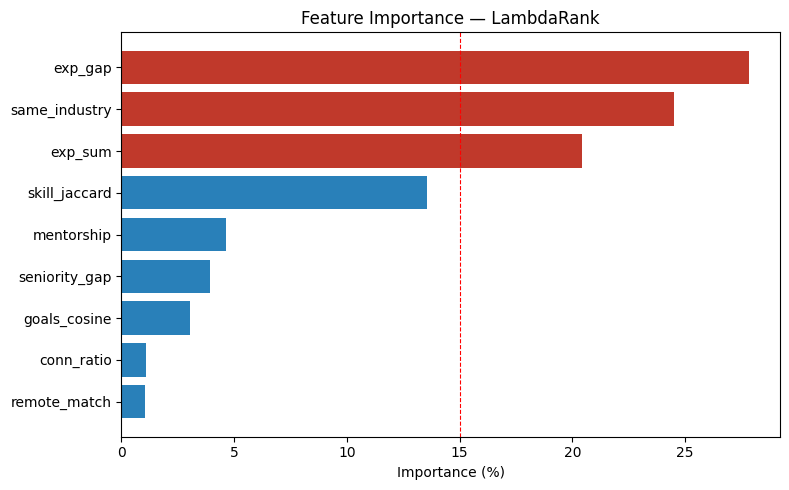

      feature  importance
      exp_gap   27.810596
same_industry   24.492199
      exp_sum   20.404107
skill_jaccard   13.543326
   mentorship    4.633610
seniority_gap    3.933989
 goals_cosine    3.049225
   conn_ratio    1.071402
 remote_match    1.061547


In [13]:
import matplotlib.pyplot as plt

imp_df = pd.DataFrame({
    'feature'    : FEATURE_NAMES,
    'importance' : model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

imp_df['importance'] = imp_df['importance'] / imp_df['importance'].sum() * 100

colors = ['#c0392b' if v > 15 else '#2980b9' for v in imp_df['importance']]
plt.figure(figsize=(8, 5))
plt.barh(imp_df['feature'], imp_df['importance'], color=colors)
plt.axvline(15, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Importance (%)')
plt.title('Feature Importance — LambdaRank')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print(imp_df[::-1].to_string(index=False))

In [14]:
# TWO functions here:
#   recommend_connections() — same as before, pure score ranking
#   mmr_recommend()         — NEW: adds diversity so results are not all same industry/level

def build_feature_matrix(profile_id, candidate_ids):
    """Builds all candidate feature rows as one matrix — fast batch prediction."""
    ia = profile_id_to_idx.get(profile_id)
    if ia is None:
        return None, []

    a      = profiles.iloc[ia]
    exp_a  = float(a['years_experience']) if pd.notna(a['years_experience']) else 0.0
    conn_a = max(float(a['connections'])  if pd.notna(a['connections'])  else 1.0, 1.0)
    sen_a  = int(a['seniority_ord'])
    r_a    = int(a['remote_enc'])

    rows, valid_ids = [], []
    for cid in candidate_ids:
        ib = profile_id_to_idx.get(cid)
        if ib is None:
            continue
        b      = profiles.iloc[ib]
        exp_b  = float(b['years_experience']) if pd.notna(b['years_experience']) else 0.0
        conn_b = max(float(b['connections'])  if pd.notna(b['connections'])  else 1.0, 1.0)
        sen_b  = int(b['seniority_ord'])

        rows.append([
            jaccard(a['skills_list'], b['skills_list']),                            # skill_jaccard
            float(cosine_similarity(goals_matrix[ia], goals_matrix[ib])[0][0]),    # goals_cosine
            abs(exp_a - exp_b),                                                     # exp_gap
            1 if a['industry_enc'] == b['industry_enc'] else 0,                    # same_industry
            abs(sen_a - sen_b),                                                     # seniority_gap
            max(conn_a, conn_b) / min(conn_a, conn_b),                             # conn_ratio
            exp_a + exp_b,                                                          # exp_sum
            1 if (max(sen_a, sen_b) >= 2 and min(sen_a, sen_b) <= 1) else 0,      # mentorship
            2 - abs(r_a - int(b['remote_enc']))                                    # remote_match
        ])
        valid_ids.append(cid)

    return np.array(rows, dtype=np.float32), valid_ids


def recommend_connections(profile_id, top_n=10):
    """Pure score ranking — fastest, no diversity control."""
    if profile_id not in profile_id_to_idx:
        print(f"Profile not found: {profile_id}")
        return None

    candidates          = [p for p in profiles['profile_id'] if p != profile_id]
    feat_matrix, ids    = build_feature_matrix(profile_id, candidates)
    if feat_matrix is None:
        return None

    scores = model.predict(feat_matrix)
    top    = pd.DataFrame({'profile_id': ids, 'rank_score': scores}) \
               .nlargest(top_n, 'rank_score').reset_index(drop=True)
    top.index += 1

    return top.merge(
        profiles[['profile_id','name','current_role','current_company',
                  'industry','seniority_level','years_experience','remote_preference']],
        on='profile_id', how='left'
    )[['name','current_role','current_company','industry',
       'seniority_level','years_experience','remote_preference','rank_score']]


def mmr_recommend(profile_id, top_n=10, fetch_n=60, diversity=0.3):
    """
    MMR (Maximal Marginal Relevance) recommender — adds diversity.

    How it works:
      1. Score all 50K candidates with the model (same as recommend_connections)
      2. Keep the top 60 by raw score (fetch_n)
      3. Pick results one-by-one:
           - each pick = best balance of (relevance to query) vs (dissimilarity to already-picked)
           - diversity=0.0 → pure relevance  (same as recommend_connections)
           - diversity=0.3 → 70% relevance + 30% diversity  ← recommended for web app
           - diversity=1.0 → pure diversity  (ignores score, just picks different people)

    Why this matters:
      Without MMR: top 10 = all Healthcare + Senior (echo chamber)
      With MMR:    top 10 = mix of industries, seniority levels, experience ranges
    """
    if profile_id not in profile_id_to_idx:
        print(f"Profile not found: {profile_id}")
        return None

    candidates       = [p for p in profiles['profile_id'] if p != profile_id]
    feat_matrix, ids = build_feature_matrix(profile_id, candidates)
    if feat_matrix is None:
        return None

    # Step 1: score everyone
    scores = model.predict(feat_matrix)

    # Step 2: keep top fetch_n candidates only (for speed)
    top_idx    = np.argsort(scores)[::-1][:fetch_n]
    top_ids    = [ids[i] for i in top_idx]
    top_scores = scores[top_idx]
    top_feats  = feat_matrix[top_idx]        # (fetch_n × 9) matrix for similarity check

    # Step 3: MMR selection loop
    selected  = []    # indices of already-chosen candidates (within top_idx)
    remaining = list(range(len(top_ids)))

    for _ in range(top_n):
        if not remaining:
            break

        best_i, best_mmr = None, -99999

        for i in remaining:
            relevance = float(top_scores[i])

            if not selected:
                mmr_score = relevance      # first pick is always highest scorer
            else:
                # similarity = cosine between this candidate and all already-selected
                sel_feats = top_feats[selected]              # (k × 9)
                cur_feat  = top_feats[i].reshape(1, -1)      # (1 × 9)
                max_sim   = float(cosine_similarity(cur_feat, sel_feats).max())
                mmr_score = (1 - diversity) * relevance - diversity * max_sim

            if mmr_score > best_mmr:
                best_mmr, best_i = mmr_score, i

        selected.append(best_i)
        remaining.remove(best_i)

    # Build final result
    final_ids    = [top_ids[i]    for i in selected]
    final_scores = [top_scores[i] for i in selected]

    result = pd.DataFrame({'profile_id': final_ids, 'rank_score': final_scores})
    result = result.merge(
        profiles[['profile_id','name','current_role','current_company',
                  'industry','seniority_level','years_experience','remote_preference']],
        on='profile_id', how='left'
    )
    result.index = range(1, len(result) + 1)
    return result[['name','current_role','current_company','industry',
                   'seniority_level','years_experience','remote_preference','rank_score']]


# ── Test both and compare ──────────────────────────────────────
pid  = profiles['profile_id'].iloc[0]
name = profiles.loc[profiles['profile_id'] == pid, 'name'].values[0]

print(f"=== Without diversity (old behaviour) — {name} ===\n")
print(recommend_connections(pid, top_n=5).to_string())

print(f"\n=== With MMR diversity=0.3 (recommended for web app) ===\n")
print(mmr_recommend(pid, top_n=5, diversity=0.3).to_string())

print("\nIn your web app, call mmr_recommend() instead of recommend_connections()")
print("Tune diversity: 0.2 = slight mix  |  0.3 = good balance  |  0.5 = very diverse")

=== Without diversity (old behaviour) — Daniel Doyle ===

              name            current_role current_company    industry seniority_level  years_experience remote_preference  rank_score
0  Justin Williams                Director            Uber  Healthcare          senior                 9            hybrid    5.744133
1       Mary Young         Senior Designer         NextGen  Healthcare          senior                 9            onsite    5.651946
2    Joshua Powell  Senior Product Manager         NextGen  Healthcare          senior                 8            onsite    5.556317
3       Mary Brown  Senior Product Manager         NextGen  Healthcare          senior                 8            onsite    5.514501
4       Erik Brown  Senior Product Manager       RapidGrow  Healthcare          senior                 9            onsite    5.511399

=== With MMR diversity=0.3 (recommended for web app) ===

              name            current_role current_company    industry se

In [15]:
model.save_model("recommendation_model_lambdarank.txt")

joblib.dump(tfidf_skills,    "tfidf_skills.pkl")
joblib.dump(tfidf_goals,     "tfidf_goals.pkl")
joblib.dump(tfidf_can_offer, "tfidf_can_offer.pkl")
joblib.dump(tfidf_needs,     "tfidf_needs.pkl")
joblib.dump(tfidf_about,     "tfidf_about.pkl")
joblib.dump(oe_seniority,    "oe_seniority.pkl")
joblib.dump(le_industry,     "le_industry.pkl")
joblib.dump(le_city,         "le_city.pkl")
profiles.to_csv("profiles_encoded.csv", index=False)

print("Saved — load in Flask with:")
print("  model = lgb.Booster(model_file='recommendation_model_lambdarank.txt')")
print("  scores = model.predict(feat_matrix)")

Saved — load in Flask with:
  model = lgb.Booster(model_file='recommendation_model_lambdarank.txt')
  scores = model.predict(feat_matrix)
